# 와인 품질 예측하기


![](https://labelyourdata.com/img/article-illustrations/ml_essential_tool.jpg)

## 1.환경준비

### (1) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.backend import clear_session
from keras.optimizers import Adam

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

In [3]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/winequality-white.csv"
data = pd.read_csv(path)
data['quality'] = np.where(data['quality'] == 3, 4, np.where(data['quality'] == 9, 8, data['quality']))
data['quality'] = data['quality'] - 4
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,2
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,2
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,2
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,2
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,2


* 범주가 5개 입니다.
    * 0 - 최하  ~  4 - 최상

In [4]:
data['quality'].value_counts()   # 범주 5개

,count
quality,
2,2198
1,1457
3,880
0,183
4,180


## 2.데이터 준비

### (1) 데이터 준비
* y에 대한 전처리 : 위에서 이미 0 ~ 4로 범주를 맞췄습니다.
* x, y 나누기

In [5]:
target = 'quality'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

### (2) 데이터 분할

In [6]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size= .3, random_state = 20)

### (3) 스케일링

In [7]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## 3.모델링

최소 3개 이상의 모델을 생성하고 성능을 비교하시오.

In [8]:
nfeatures = x_train.shape[1]
nfeatures

11

### (1) 모델1

In [20]:
model = Sequential([Input(shape=(nfeatures, )),
                    Dense(64, activation='relu'),
                    Dense(28, activation='relu'),
                    Dense(14, activation='relu'),
                    Dense(5, activation='softmax')])   # 입력 층 'quality'의 범주 수는 5개이기 때문에 출력층도 5개이어야 한다.

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 28)                  │           1,820 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 14)                  │             406 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 5)                   │              75 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,069 (11.99 KB)

 Trainable params: 3,069 (11.99 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

result = model.fit(x_train, y_train, validation_split=0.2, epochs=50).history

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4322 - loss: 1.3305 - val_accuracy: 0.5262 - val_loss: 1.0494
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5146 - loss: 1.1516 - val_accuracy: 0.5394 - val_loss: 1.0729
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5135 - loss: 1.1167 - val_accuracy: 0.5437 - val_loss: 0.9927
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5208 - loss: 1.0723 - val_accuracy: 0.5641 - val_loss: 0.9988
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5366 - loss: 1.0796 - val_accuracy: 0.5569 - val_loss: 0.9966
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5248 - loss: 1.0845 - val_accuracy: 0.5787 - val_loss: 0.9718
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5146 - loss: 1.0977 - val_accuracy: 0.5729 - val_loss: 0.9746
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5305 - loss: 1.0552 - val_accuracy: 0.5612 - val_loss:

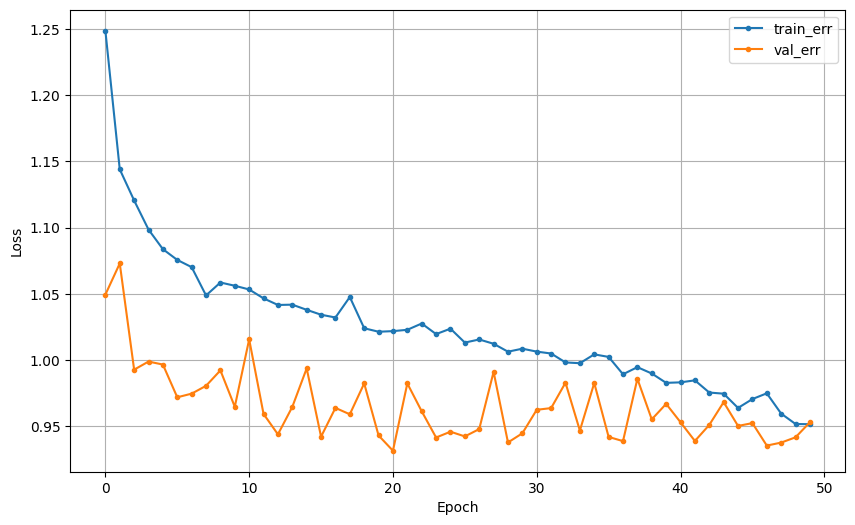

In [22]:
dl_history_plot(result)

In [24]:
pred = model.predict(x_val)
pred[:5]   # 확률 값으로 출력된다.

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.00152759, 0.05959056, 0.496708  , 0.3911884 , 0.0509855 ],
       [0.00699654, 0.16975668, 0.5020537 , 0.291011  , 0.03018213],
       [0.00526251, 0.06747066, 0.5230056 , 0.34364483, 0.06061633],
       [0.07151105, 0.29549053, 0.48366168, 0.1356724 , 0.01366435],
       [0.00928907, 0.09945808, 0.5773985 , 0.27877846, 0.03507582]],
      dtype=float32)

In [25]:
# 확률값으로 예측이 출력되기 때문에 argmax로 가장 최대값의 인덱스를 반환해주도록 변경한다.
pred = np.argmax(pred, axis = 1)
pred[:5]

array([2, 2, 2, 2, 2])

In [26]:
print(classification_report(y_val, pred))
print(confusion_matrix(y_val, pred))

              precision    recall  f1-score   support

           0       0.54      0.11      0.19        61
           1       0.59      0.59      0.59       438
           2       0.53      0.63      0.58       660
           3       0.42      0.38      0.39       250
           4       0.40      0.13      0.20        61

    accuracy                           0.53      1470
   macro avg       0.50      0.37      0.39      1470
weighted avg       0.52      0.53      0.52      1470

[[  7  35  19   0   0]
 [  4 258 167   6   3]
 [  2 140 413  99   6]
 [  0   6 147  94   3]
 [  0   0  26  27   8]]


### (2) 모델2

In [56]:
# 위의 모델에서 높은 성능을 가지는 모델 구현해보기

model = Sequential([Input(shape=(nfeatures, )),
                    Dense(10, activation='relu'),
                    Dense(10, activation='relu'),
                    Dense(5, activation='relu'),
                    Dense(5, activation='relu'),
                    Dense(5, activation='softmax')])   # 입력 층 'quality'의 범주 수는 5개이기 때문에 출력층도 5개이어야 한다.

model.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                     │ (None, 10)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 5)                   │              55 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ (None, 5)                   │              30 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 345 (1.35 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

result = model.fit(x_train, y_train, validation_split=0.2, epochs=100).history

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4173 - loss: 1.3860 - val_accuracy: 0.4650 - val_loss: 1.2149
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4551 - loss: 1.2707 - val_accuracy: 0.4650 - val_loss: 1.1956
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4571 - loss: 1.2747 - val_accuracy: 0.4650 - val_loss: 1.1524
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4688 - loss: 1.2070 - val_accuracy: 0.5350 - val_loss: 1.0512
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5130 - loss: 1.1502 - val_accuracy: 0.5452 - val_loss: 1.0272
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5052 - loss: 1.1697 - val_accuracy: 0.5423 - val_loss: 1.0369
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5038 - loss: 1.1363 - val_accuracy: 0.5452 - val_loss: 1.0255
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5216 - loss: 1.1256 - val_accuracy: 0.5612 - v

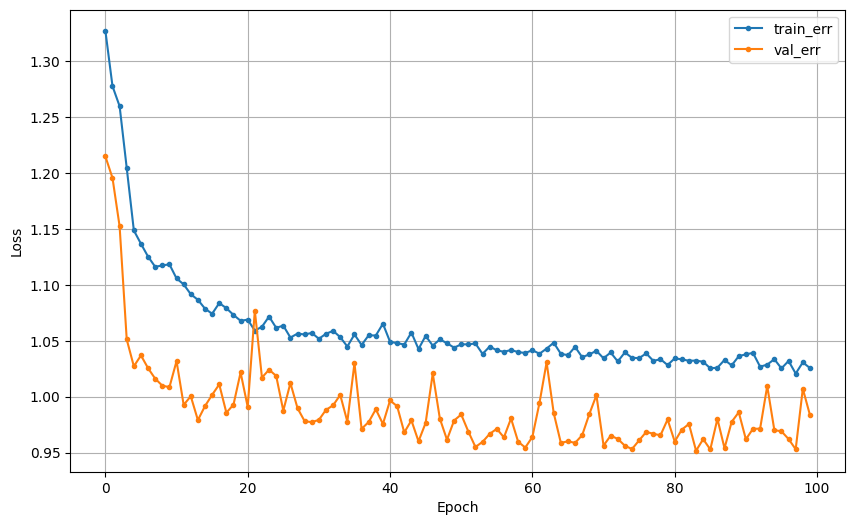

In [58]:
dl_history_plot(result)

In [59]:
pred = model.predict(x_val)
# pred[:5]   # 확률 값으로 출력된다.
pred = np.argmax(pred, axis = 1)
pred[:5]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([2, 2, 2, 2, 2])

In [60]:
print(classification_report(y_val, pred))
print(confusion_matrix(y_val, pred))

              precision    recall  f1-score   support

           0       0.45      0.21      0.29        61
           1       0.62      0.39      0.48       438
           2       0.51      0.78      0.62       660
           3       0.42      0.28      0.34       250
           4       0.00      0.00      0.00        61

    accuracy                           0.52      1470
   macro avg       0.40      0.33      0.35      1470
weighted avg       0.51      0.52      0.49      1470

[[ 13  26  21   1   0]
 [ 11 171 251   5   0]
 [  5  78 512  65   0]
 [  0   1 178  71   0]
 [  0   0  34  27   0]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### (3) 모델3